# 03. 미들웨어 기반 컨텍스트 엔지니어링 (Context Engineering with Middleware)

> 이 노트북은 LangChain v1 **미들웨어**(`@dynamic_prompt`, `@wrap_model_call`, `SummarizationMiddleware`, `Store`)를 중심으로 컨텍스트를 엔지니어링해요. Deep Agents SDK를 기반으로 한 5가지 컨텍스트 타입 관점은 **`10_Deep_Agents/03-Context-Engineering.ipynb`** 에서 따로 다뤄요.

에이전트를 구축할 때 가장 어려운 부분은 **신뢰성(reliability)**을 확보하는 것이에요. MVP 단계에서 잘 동작하던 에이전트가 실제 환경에서 실패하는 이유는 대부분 하나예요 -- LLM에 **올바른 컨텍스트**가 전달되지 않아서입니다.

**컨텍스트 엔지니어링(Context Engineering)**은 LLM이 작업을 성공적으로 완수할 수 있도록 올바른 정보, 도구, 지시사항을 올바른 형식으로 제공하는 기술이에요. 이것이 AI 엔지니어의 가장 중요한 역량 중 하나입니다.

> 🔑 **핵심 개념**: 프롬프트 엔지니어링이 "LLM에게 **무엇을** 시킬까?"라면, 컨텍스트 엔지니어링은 "LLM이 **성공하려면** 어떤 정보가 필요할까?"예요. 비유하자면, 프롬프트 엔지니어링은 시험 문제를 잘 내는 것이고, 컨텍스트 엔지니어링은 학생에게 **필요한 참고 자료를 적절한 시점에 제공**하는 것이에요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **컨텍스트 3종류**(Model, Tool, Life-cycle)의 차이와 지속성을 설명할 수 있어요
2. **데이터 소스 3가지**(Runtime Context, State, Store)를 적절히 선택해 활용할 수 있어요
3. `@dynamic_prompt`로 State/Store/Runtime Context 기반 **동적 시스템 프롬프트**를 구현할 수 있어요
4. `@wrap_model_call`로 도구 필터링과 모델 선택을 **런타임에 동적으로 제어**할 수 있어요
5. **RBAC(역할 기반 접근 제어)**를 미들웨어로 구현할 수 있어요

## 사전 지식

- `02-Human-In-The-Loop-V1.ipynb`: 미들웨어 기반 HITL, HumanInTheLoopMiddleware
- `01-Middleware-Basics.ipynb`: `@dynamic_prompt`, `@wrap_model_call` 기본 사용법

## 컨텍스트 엔지니어링 전체 구조

이 장의 핵심은 **"무엇을 어디서 읽고, 무엇을 바꾸는가?"**를 분리해서 보는 것입니다. 컨텍스트 엔지니어링은 아래 흐름으로 동작해요.

> **데이터 소스에서 값을 읽고 → 미들웨어/도구가 결정을 내리고 → 모델 호출·도구 실행·실행 생명주기에 반영한다.**

여기서 헷갈리기 쉬운 점은 **데이터 소스**와 **컨텍스트 타입**이 서로 다른 축이라는 거예요.

- **데이터 소스**: 판단에 필요한 값을 어디서 가져오는가? (`Runtime Context`, `State`, `Store`)
- **컨텍스트 타입**: 그 값을 이용해 무엇을 바꾸는가? (`Model Context`, `Tool Context`, `Life-cycle Context`)

```mermaid
flowchart LR
    subgraph Sources["① 데이터 소스: 어디서 값을 읽나"]
        RC["Runtime Context<br/>호출 때 주입되는 설정<br/>user_id, role, env"]
        ST["State<br/>현재 대화의 단기 상태<br/>messages, 인증, 업로드 파일"]
        STORE["Store<br/>대화 밖 장기 메모리<br/>선호도, 히스토리"]
    end

    subgraph Mechanisms["② 구현 위치: 값을 읽어 결정하는 코드"]
        DP["@dynamic_prompt<br/>시스템 프롬프트 생성"]
        WMC["@wrap_model_call<br/>메시지·도구·모델 수정"]
        TR["ToolRuntime<br/>도구 내부에서 읽기·쓰기"]
        MW["Middleware hooks<br/>요약·가드레일·로깅"]
    end

    subgraph Effects["③ 컨텍스트 타입: 실제로 무엇이 바뀌나"]
        MC["Model Context<br/>이번 모델 호출에 보이는 내용"]
        TC["Tool Context<br/>도구가 읽고 저장하는 상태"]
        LC["Life-cycle Context<br/>에이전트 실행 흐름과 기록"]
    end

    RC --> DP
    ST --> DP
    STORE --> DP
    RC --> WMC
    ST --> WMC
    STORE --> WMC
    RC --> TR
    ST --> TR
    STORE --> TR
    ST --> MW

    DP --> MC
    WMC --> MC
    TR --> TC
    MW --> LC

    classDef source fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef mechanism fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef effect fill:#cce5ff,stroke:#007bff,color:#004085

    class RC,ST,STORE source
    class DP,WMC,TR,MW mechanism
    class MC,TC,LC effect
```

### 차트 읽는 법

1. **왼쪽(데이터 소스)**은 "판단 근거"예요. 예를 들어 `user_role`, `messages`, 사용자 선호도 같은 값입니다.
2. **가운데(구현 위치)**는 그 값을 실제로 읽는 코드예요. 이 장에서는 `@dynamic_prompt`, `@wrap_model_call`, `ToolRuntime`, `SummarizationMiddleware`를 사용합니다.
3. **오른쪽(컨텍스트 타입)**은 최종적으로 바뀌는 대상이에요. 모델에게 보이는 내용이 바뀌면 Model Context, 도구가 State/Store를 읽거나 쓰면 Tool Context, 실행 과정 자체가 요약·로깅·가드레일로 바뀌면 Life-cycle Context입니다.

> 예: `Runtime Context → @dynamic_prompt → Model Context`는 "호출 시 전달된 사용자 역할을 읽어서 이번 모델 호출의 시스템 프롬프트를 다르게 만든다"는 뜻이에요.
>
> 예: `Store → ToolRuntime → Tool Context`는 "도구가 장기 저장소에서 사용자 설정을 읽거나 새 설정을 저장한다"는 뜻이에요.

> 🔑 **핵심 개념**: Model Context 변경은 보통 **단일 모델 호출에만 적용되는 일시적(Transient)** 변경이에요. 반대로 Tool Context와 Life-cycle Context는 State/Store를 수정해 이후 턴에도 영향을 줄 수 있으므로 **지속적(Persistent)** 변경으로 봅니다.


## 컨텍스트 타입과 데이터 소스 정리

컨텍스트 엔지니어링을 설계할 때는 먼저 **변경 대상**을 고르고, 그 다음 **데이터 소스**를 고르면 이해가 쉬워요.

### 1) 무엇을 바꾸는가? — 컨텍스트 타입

| 구분 | 쉽게 말하면 | 바꾸는 대상 | 지속성 | 구현 방법 |
|------|------------|------------|--------|----------|
| **Model Context** | "이번 모델 호출에 무엇을 보여줄까?" | 시스템 프롬프트, 메시지, 도구 목록, 모델, 응답 형식 | 주로 Transient | `@dynamic_prompt`, `@wrap_model_call` |
| **Tool Context** | "도구가 무엇을 읽고 저장할 수 있을까?" | `runtime.state`, `runtime.context`, `runtime.store`, `Command(update=...)` | Persistent 가능 | `ToolRuntime`, `Command(update=...)`, `store.put()` |
| **Life-cycle Context** | "에이전트 실행 중간에 어떤 공통 처리를 할까?" | 요약, 가드레일, 로깅, 실행 제어 | Persistent 가능 | `SummarizationMiddleware` 등 미들웨어 훅 |

### 2) 어디서 값을 가져오는가? — 데이터 소스

| 데이터 소스 | 다른 이름 | 범위 | 예시 | 선택 기준 |
|------------|---------|------|------|----------|
| **Runtime Context** | 호출 시 주입되는 정적 구성 | 호출 단위 | `user_id`, `user_role`, API 키, 배포 환경 | 서버가 검증해 넣어주는 값, 사용자 요청문에 직접 넣으면 위험한 값 |
| **State** | 단기 메모리 | 대화 세션 | 메시지, 인증 상태, 업로드 파일, 현재 작업 단계 | 현재 대화 안에서 변하고 다음 턴에도 이어져야 하는 값 |
| **Store** | 장기 메모리 | 대화 간 공유 | 사용자 선호도, 검색 히스토리, 장기 기억 | 새로운 대화에서도 유지되어야 하는 사용자/업무 데이터 |

### 3) 3×3 매트릭스로 보는 대표 설계 질문

아래 표는 "데이터 소스 × 컨텍스트 타입" 조합을 설계 질문으로 바꾼 것입니다. 모든 칸을 매번 구현해야 한다는 뜻이 아니라, **필요한 칸만 선택하는 체크리스트**로 보면 됩니다.

| 데이터 소스 ↓ / 변경 대상 → | **Model Context**<br/>모델 호출 제어 | **Tool Context**<br/>도구 읽기·쓰기 | **Life-cycle Context**<br/>실행 흐름 제어 |
|---|---|---|---|
| **Runtime Context** | 역할/환경에 따라 프롬프트·도구·모델을 다르게 할까? | 도구가 `user_id`, 권한, 연결 정보를 안전하게 사용해야 할까? | 운영 환경이나 플래그에 따라 로깅·가드레일 정책을 바꿀까? |
| **State** | 메시지 수, 인증 상태, 업로드 파일을 모델 요청에 반영할까? | 도구가 현재 세션 상태를 읽거나 `Command(update=...)`로 갱신해야 할까? | 메시지 수/토큰 수가 많아지면 요약해야 할까? |
| **Store** | 사용자 선호도나 장기 기억으로 응답 스타일을 개인화할까? | 도구가 설정, 히스토리, 메모리를 읽고 저장해야 할까? | 저장된 정책이나 장기 기억을 바탕으로 공통 처리를 조정할까? |

### 4) 이 노트북의 예제가 차트에서 차지하는 위치

| 섹션 | 차트의 흐름 | 배우는 API | 핵심 질문 |
|---|---|---|---|
| 1장 | State/Store/Runtime Context → `@dynamic_prompt` → Model Context | `@dynamic_prompt` | 시스템 프롬프트를 상황별로 어떻게 바꿀까? |
| 2장 | State → `@wrap_model_call` → Model Context | `request.override(messages=...)` | 모델에게 추가 파일 정보를 어떻게 주입할까? |
| 3장 | State/Runtime Context → `@wrap_model_call` → Model Context | `request.override(tools=...)` | 사용자가 볼 수 있는 도구 목록을 어떻게 제한할까? |
| 4장 | Runtime Context/State/Store → `ToolRuntime` → Tool Context | `ToolRuntime`, `Command`, `store.put()` | 도구가 상태를 읽고 저장하려면 무엇이 필요할까? |
| 5장 | State → Middleware hooks → Life-cycle Context | `SummarizationMiddleware` | 대화가 길어질 때 실행 과정에서 자동으로 무엇을 할까? |
| 6장 | 여러 흐름 조합 | 미들웨어 리스트 조합 | 실무 에이전트에서 여러 컨텍스트 결정을 어떻게 함께 적용할까? |


## 환경 설정

In [1]:
# 환경 변수 로드 (.env 파일에서 API 키 등을 읽어요)
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# LangSmith 추적 설정 (에이전트 컨텍스트 흐름을 모니터링해요)
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Context-Engineering"

# LangSmith 추적이 활성화되었어요.
# print(f"프로젝트: {os.environ['LANGCHAIN_PROJECT']}")

## 1. Model Context: 동적 시스템 프롬프트 (`@dynamic_prompt`)

Model Context는 **LLM이 이번 호출에서 실제로 보게 되는 입력**을 뜻해요. 시스템 프롬프트, 대화 메시지, 사용 가능한 도구, 모델 종류, 응답 형식이 모두 Model Context에 포함됩니다.

`@dynamic_prompt`는 그중에서도 **시스템 프롬프트를 매번 다시 만드는 가장 단순한 미들웨어**예요. 고정된 프롬프트 대신 State/Store/Runtime Context를 읽어서 사용자별·상황별 지시사항을 만듭니다.

`@dynamic_prompt` 함수는 `ModelRequest`를 받아 문자열을 반환해요. 반환된 문자열이 이번 모델 호출의 시스템 프롬프트로 사용됩니다.

이 절을 읽을 때는 각 예제를 다음 네 단계로 따라가면 됩니다.

1. **어떤 데이터 소스를 읽는가?** — `request.messages`, `request.runtime.store`, `request.runtime.context`
2. **무슨 판단을 하는가?** — 메시지가 긴가, 선호도가 있는가, 역할이 무엇인가
3. **프롬프트가 어떻게 바뀌는가?** — 간결하게 답하기, 친근한 톤, 읽기 전용 권한 안내
4. **지속되는가?** — 프롬프트 변경 자체는 이번 모델 호출에만 적용되므로 보통 Transient입니다.

> 🎯 **강의 포인트**: `@dynamic_prompt`는 **State 기반**, **Store 기반**, **Runtime Context 기반** 세 가지 방식으로 활용할 수 있어요. 같은 "프롬프트 변경"이라도 어떤 데이터 소스를 읽는지에 따라 설계 의도가 달라집니다.


### 1-1. State 기반 동적 프롬프트

대화 State에 따라 시스템 프롬프트를 조정해요. 예를 들어, 메시지가 많아질수록 더 간결하게 응답하도록 지시할 수 있어요.

In [ ]:
# 에이전트 생성 및 미들웨어 관련 import
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

# 기본 도구 정의 (검색 시뮬레이션)
@tool
def search_tool(query: str) -> str:
    """정보를 검색합니다."""
    return f"{query}에 대한 검색 결과: 관련 정보가 발견되었어요."

# 기본 모델: gpt-4o-mini (비용 효율적)
# 다른 옵션: "anthropic:claude-sonnet-4-5", "ollama:llama3"
model = init_chat_model("openai:gpt-4o-mini")


# --- Custom State 스키마 정의 ---
# State에 커스텀 필드를 추가하려면 TypedDict를 정의하고
# create_agent에 state_schema= 파라미터로 전달해야 해요.
# 표준 AgentState는 messages만 지원하기 때문에, 추가 필드는
# 반드시 별도 스키마로 등록해야 runtime.state에서 접근 가능해요.

class FileAgentState(TypedDict):
    """파일 업로드 컨텍스트를 포함한 커스텀 State"""
    messages: Annotated[list, add_messages]
    uploaded_files: list

class ToolFilterState(TypedDict):
    """인증 상태 기반 도구 필터링을 위한 커스텀 State"""
    messages: Annotated[list, add_messages]
    authenticated: bool

class SessionAgentState(TypedDict):
    """세션 인증 정보를 포함한 커스텀 State"""
    messages: Annotated[list, add_messages]
    authenticated: bool
    user_name: str
    session_start: str 
# ---------------------------------


@dynamic_prompt
def state_aware_prompt(request: ModelRequest) -> str:
    """State의 메시지 수에 따라 시스템 프롬프트를 동적으로 조정해요"""
    # request.messages는 request.state["messages"]의 단축형이에요
    message_count = len(request.messages)

    base = "당신은 도움이 되는 한국어 어시스턴트예요."

    if message_count > 10:
        # 긴 대화: 더 간결하게 응답하도록 지시
        base += "\n이 대화는 길어지고 있어요 - 매우 간결하게 답변해요. 1-2문장으로 제한해요."
    elif message_count > 5:
        # 중간 대화: 일반 간결체 유지
        base += "\n적당히 간결하게 답변해요."
    else:
        # 짧은 대화: 상세하게 설명
        base += "\n친절하고 상세하게 설명해요."

    print(f"[프롬프트 조정] 메시지 수: {message_count}개 → {base[-30:]}...")
    return base


# 미들웨어를 포함한 에이전트 생성
agent = create_agent(
    model=model,
    tools=[search_tool],
    middleware=[state_aware_prompt]
)

# 짧은 대화 테스트 (1개 메시지)
result = agent.invoke({
    "messages": [{"role": "user", "content": "머신러닝이 뭔가요?"}]
})
print("\n응답:", result["messages"][-1].content[:200])

[프롬프트 조정] 메시지 수: 1개 → 는 한국어 어시스턴트예요.
친절하고 상세하게 설명해요....

응답: 머신러닝(Machine Learning)은 인공지능(AI)의 한 분야로, 컴퓨터가 명시적인 프로그래밍 없이도 데이터를 통해 학습하고 예측할 수 있도록 하는 기술입니다. 머신러닝의 주요 목표는 데이터를 분석하고, 그로부터 패턴을 인식하며, 이러한 패턴을 기반으로 미래의 데이터나 상황에 대한 예측을 수행하는 것입니다.

머신러닝은 크게 세 가지 유형으로 분류할


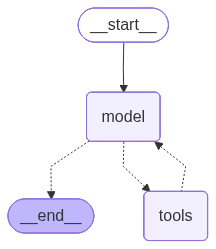

In [4]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent 노드: state_aware_prompt 미들웨어가 메시지 수에 따라 시스템 프롬프트를 동적 조정해요
# tools 노드: tool_call이 있으면 도구를 실행해요
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

### 1-2. Store 기반 동적 프롬프트

Store(장기 메모리)에 저장된 사용자 선호도를 읽어 개인화된 시스템 프롬프트를 만들어요. 같은 질문에 사용자마다 다른 스타일로 답변하는 개인화 경험을 구현할 수 있어요.

> 🔑 **핵심 개념**: `request.runtime.store`로 Store에 접근해요. `store.get((네임스페이스,), 키)` 형태로 데이터를 읽어요.

In [5]:
# Store와 컨텍스트 스키마 관련 import
from dataclasses import dataclass
from langgraph.store.memory import InMemoryStore
from langchain.messages import HumanMessage


# Runtime Context 스키마 정의 (user_id를 전달해요)
@dataclass
class UserContext:
    user_id: str


@dynamic_prompt
def store_aware_prompt(request: ModelRequest) -> str:
    """Store에서 사용자 선호도를 읽어 시스템 프롬프트를 개인화해요"""
    # Runtime Context에서 user_id 추출
    user_id = request.runtime.context.user_id

    # Store에서 사용자 선호도 읽기
    store = request.runtime.store
    user_prefs = store.get(("preferences",), user_id)

    base = "당신은 도움이 되는 어시스턴트예요."

    if user_prefs:
        # Store에서 선호도 발견: 개인화된 프롬프트 적용
        style = user_prefs.value.get("communication_style", "")
        base += f"\n사용자 선호 응답 스타일: {style}"
        print(f"[Store] user_id={user_id} → 선호도 발견: {style[:50]}...")
    else:
        # Store에 선호도 없음: 기본 스타일 사용
        base += "\n전문적이고 공손한 톤으로 3문장 이내로 답변해요."
        print(f"[Store] user_id={user_id} → 선호도 없음, 기본 스타일 사용")

    return base


# Store 생성 및 사용자 선호도 초기화
store = InMemoryStore()
store.put(
    ("preferences",),
    "alice",
    {
        "communication_style": """
        emoji를 풍부하게 사용하고, 불릿 포인트로 핵심만 정리해요.
        친근하고 활발한 어조로 짧게 답변해요.
        """
    },
)

# 에이전트 생성 (Store와 Context 스키마 연결)
agent = create_agent(
    model=model,
    tools=[search_tool],
    middleware=[store_aware_prompt],
    context_schema=UserContext,
    store=store,
)

# alice: Store에 선호도 있음 → 개인화된 스타일
# === alice (선호도 있음) ===
result = agent.invoke(
    {"messages": [HumanMessage(content="파이썬을 배우는 방법을 알려줘")]},
    context=UserContext(user_id="alice"),
)
print("응답:", result["messages"][-1].content)

[Store] user_id=alice → 선호도 발견: 
        emoji를 풍부하게 사용하고, 불릿 포인트로 핵심만 정리해요.
     ...
[Store] user_id=alice → 선호도 발견: 
        emoji를 풍부하게 사용하고, 불릿 포인트로 핵심만 정리해요.
     ...
응답: 파이썬을 배우는 방법은 다양해요! 🌟 아래의 단계들을 참고해 보세요:

- **온라인 강의 수강** 🎓
  - Udemy, Coursera, edX에서 강좌 찾아보기
- **튜토리얼 및 문서** 📚
  - 공식 파이썬 문서 및 W3Schools 활용
- **코드 작성 해보기** 💻
  - 간단한 프로젝트나 문제 풀이 시작하기
- **커뮤니티 참여** 🧑‍🤝‍🧑
  - Stack Overflow, GitHub 등에서 질문하고 답하기
- **책 읽기** 📘
  - 추천: "Automate the Boring Stuff with Python", "Python Crash Course"

파이썬을 배워서 멋진 프로젝트를 만들어 보세요! 🚀✨


In [6]:
# bob: Store에 선호도 없음 → 기본 스타일
# === bob (선호도 없음) ===
result = agent.invoke(
    {"messages": [HumanMessage(content="파이썬을 배우는 방법을 알려줘")]},
    context=UserContext(user_id="bob"),
)
print("응답:", result["messages"][-1].content)

[Store] user_id=bob → 선호도 없음, 기본 스타일 사용
응답: 파이썬을 배우는 가장 효과적인 방법은 다음과 같습니다. 첫째, 온라인 강의나 튜토리얼을 통해 기본 문법과 개념을 익히고, 둘째, 실제 프로젝트를 수행하여 실습을 통해 경험을 쌓는 것이 중요합니다. 마지막으로, 커뮤니티에 참여하거나 포럼에서 질문하여 해결책을 찾아보는 것도 큰 도움이 됩니다.


### 1-3. Runtime Context 기반 동적 프롬프트

에이전트 호출 시 전달하는 Runtime Context를 기반으로 시스템 프롬프트를 동적으로 생성해요. Runtime Context 값은 한 번의 실행 중에는 변하지 않는 정적 구성값이지만, 호출마다 다른 `user_role`, `deployment_env` 등을 주입할 수 있으므로 결과 프롬프트는 달라집니다.

> 💡 **실무 팁**: Runtime Context는 인증 레이어에서 검증된 정보(user_role, permissions)를 전달하기에 적합해요. State나 Store와 달리 에이전트 외부에서 주입되므로 변조 위험이 낮아요.

In [7]:
# 역할과 환경을 포함한 Runtime Context 스키마
@dataclass
class RoleContext:
    user_role: str       # "admin", "editor", "viewer"
    deployment_env: str  # "production", "staging", "development"


@dynamic_prompt
def context_aware_prompt(request: ModelRequest) -> str:
    """Runtime Context의 사용자 역할과 환경에 따라 프롬프트를 조정해요"""
    # Runtime Context에서 역할과 환경 추출
    user_role = request.runtime.context.user_role
    env = request.runtime.context.deployment_env

    base = "당신은 데이터 관리 어시스턴트예요."

    # 역할별 권한 지시사항 추가
    if user_role == "admin":
        base += "\n관리자 권한이 있어요. 모든 작업(조회/수정/삭제)을 수행할 수 있어요."
    elif user_role == "editor":
        base += "\n편집자 권한이 있어요. 조회와 수정은 가능하지만 삭제는 불가능해요."
    elif user_role == "viewer":
        base += "\n읽기 전용 권한이 있어요. 조회만 가능하고 데이터 변경은 안 돼요."

    # 환경별 주의사항 추가
    if env == "production":
        base += "\n프로덕션 환경입니다 - 데이터 변경 시 매우 신중하게 안내해요."

    print(f"[컨텍스트] 역할: {user_role}, 환경: {env}")
    return base


agent = create_agent(
    model=model,
    tools=[search_tool],
    middleware=[context_aware_prompt],
    context_schema=RoleContext,
)

# admin 사용자 테스트
# === admin 사용자 ===
result = agent.invoke(
    {"messages": [{"role": "user", "content": "고객 데이터를 수정할 수 있나요?"}]},
    context=RoleContext(user_role="admin", deployment_env="production"),
)
print("응답:", result["messages"][-1].content)

[컨텍스트] 역할: admin, 환경: production
응답: 네, 고객 데이터를 수정할 수 있습니다. 하지만 프로덕션 환경에서 중요한 데이터 변경을 수행하기 전에 데이터 수정 사항에 대한 구체적인 내용을 알려주시면 신중히 진행하겠습니다. 수정할 고객 데이터의 세부 사항을 제공해 주시겠어요?


In [8]:
# viewer 사용자 테스트
# === viewer 사용자 ===
result = agent.invoke(
    {"messages": [{"role": "user", "content": "고객 데이터를 수정할 수 있나요?"}]},
    context=RoleContext(user_role="viewer", deployment_env="production"),
)
print("응답:", result["messages"][-1].content)

[컨텍스트] 역할: viewer, 환경: production
응답: 아니요, 고객 데이터를 수정할 수 없습니다. 저는 읽기 전용 권한만 가지고 있어 조회만 가능하고 데이터 변경은 할 수 없습니다. 다른 데이터 관련 질문이 있다면 도와드릴 수 있습니다!


## 2. Model Context: 메시지 주입 (`@wrap_model_call`)

`@dynamic_prompt`가 시스템 프롬프트 문자열만 바꾼다면, `@wrap_model_call`은 모델 호출 전체를 감싸서 **메시지, 도구 목록, 모델, 응답 형식**까지 수정할 수 있어요.

실행 흐름은 다음과 같습니다.

1. 모델 호출 직전에 `request`를 받습니다.
2. `request.state`, `request.runtime.context`, `request.runtime.store` 등을 읽습니다.
3. 필요하면 `request.override(...)`로 Model Context를 바꿉니다.
4. 마지막에 `handler(request)`를 호출해 실제 모델 호출을 진행합니다.

이 절의 예제는 **State에 들어 있는 업로드 파일의 실제 텍스트 내용**을 읽어 메시지로 주입합니다. 즉, 차트로 보면 `State → @wrap_model_call → Model Context` 흐름이에요.

> 🎯 **강의 포인트**: `request.override(messages=..., tools=..., model=...)`는 "이번 모델 호출에 전달되는 요청"을 바꾸는 작업입니다. State/Store를 저장하는 작업과는 구분해서 보세요.


### 2-1. State에서 파일 컨텍스트 주입

사용자가 업로드한 파일 정보를 State에서 읽어 모델 요청에 자동으로 추가해요. 파일 처리 에이전트를 만들 때 유용한 패턴이에요.

아래 실습은 단순히 `summary`만 넣는 가짜 업로드가 아니라, 노트북 실행 중 **샘플 CSV/Markdown 파일을 직접 생성**하고 `Path.read_text()`로 파일 내용을 읽은 뒤 `uploaded_files` State에 넣습니다. 그래서 모델은 "파일을 직접 열 수 없다"고 답하는 대신, 미들웨어가 주입한 실제 파일 내용에 근거해서 계산·요약할 수 있어요.


In [9]:
# wrap_model_call 및 타입 힌트 import
from langchain.agents.middleware import wrap_model_call, ModelResponse
from pathlib import Path
from textwrap import dedent
from typing import Callable


# ---------------------------------------------------
# 실습용 "업로드 파일" 직접 생성
# ---------------------------------------------------
# 노트북을 repo root에서 실행해도, 06_Middleware 폴더 안에서 실행해도
# 같은 위치에 샘플 파일이 만들어지도록 경로를 잡아요.
NOTEBOOK_DIR = (
    Path("06_Middleware")
    if Path("06_Middleware/03-Context-Engineering.ipynb").exists()
    else Path(".")
)
UPLOAD_DIR = NOTEBOOK_DIR / "data" / "context_uploads"
UPLOAD_DIR.mkdir(parents=True, exist_ok=True)

sample_uploads = {
    "sales_q4.csv": """
    month,region,revenue_million_krw,top_product
    2024-10,서울,120,AI 교육 패키지
    2024-11,부산,95,LangGraph 워크숍
    2024-12,서울,155,에이전트 컨설팅
    """,
    "customer_notes.md": """
    # 고객 인터뷰 요약

    - 고객 A: 자동 리포트 생성은 만족하지만, 업로드한 CSV 내용을 근거로 답하는지 확인하고 싶어함.
    - 고객 B: 파일 이름만 보고 추측하는 답변보다 실제 행(row) 값을 인용하는 답변을 선호함.
    - 공통 요청: 다음 분기에는 서울 지역 AI 교육 패키지와 에이전트 컨설팅을 묶은 패키지를 제안해 달라고 요청함.
    """,
}

for filename, content in sample_uploads.items():
    path = UPLOAD_DIR / filename
    path.write_text(dedent(content).strip() + "\n", encoding="utf-8")


def load_uploaded_text_file(path: Path, max_chars: int = 4_000) -> dict[str, str]:
    """실제 파일 내용을 읽어 Agent State에 넣을 업로드 파일 딕셔너리로 변환해요."""
    content = path.read_text(encoding="utf-8")
    return {
        "name": path.name,
        "type": path.suffix.lstrip(".").upper() or "TEXT",
        "path": str(path),
        "summary": f"실제 파일에서 읽은 텍스트 {len(content)}자",
        # 실무에서는 토큰 예산에 맞춰 chunking/RAG/요약을 사용해요.
        # 이 실습은 작은 파일이므로 원문을 그대로 Model Context에 주입합니다.
        "content": content[:max_chars],
    }


uploaded_files = [
    load_uploaded_text_file(path)
    for path in sorted(UPLOAD_DIR.iterdir())
    if path.is_file()
]

print(f"생성된 업로드 파일: {len(uploaded_files)}개")
for file in uploaded_files:
    print(f"- {file['name']} | {file['path']} | {len(file['content'])}자")


@wrap_model_call
def inject_file_context(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """State의 uploaded_files에서 실제 파일 내용을 읽어 모델 요청에 주입해요."""
    # State에서 업로드된 파일 데이터 가져오기
    uploaded_files = request.state.get("uploaded_files", [])

    if uploaded_files:
        # 파일별 실제 내용 블록 작성
        file_blocks = []
        for file in uploaded_files:
            file_blocks.append(
                f"""### {file['name']} ({file.get('type', 'TEXT')})
경로: {file.get('path', '(경로 없음)')}
요약: {file.get('summary', '(요약 없음)')}
내용:
```text
{file.get('content', '(읽은 내용 없음)')}
```"""
            )

        file_context = f"""<uploaded_files>
이 대화에서 사용 가능한 업로드 파일의 실제 내용입니다.
파일 이름만 추측하지 말고, 아래 원문 내용에 근거해 답하세요.

{chr(10).join(file_blocks)}
</uploaded_files>"""

        # 파일 컨텍스트를 이번 모델 호출에만 주입 (State 자체를 바꾸지는 않음)
        messages = [
            *request.messages,
            {"role": "user", "content": file_context},
        ]
        request = request.override(messages=messages)
        print(f"[파일 주입] {len(uploaded_files)}개 파일의 실제 내용 추가")

    # 수정된 request로 모델 호출
    return handler(request)


# 🔑 핵심: State에 커스텀 필드(uploaded_files)를 사용하려면
# state_schema=FileAgentState를 반드시 지정해야 해요.
# 그래야 agent.invoke()에서 전달한 "uploaded_files" 값이
# runtime.state(request.state)에서 접근 가능해요.
agent = create_agent(
    model=model,
    tools=[search_tool],
    middleware=[inject_file_context],
    state_schema=FileAgentState,   # 커스텀 State 스키마 등록
    system_prompt=(
        "당신은 업로드 파일 분석 어시스턴트예요. "
        "<uploaded_files> 블록에 제공된 실제 파일 내용을 근거로 답하고, "
        "파일을 열 수 없다고 말하지 마세요."
    ),
)

# 파일이 업로드된 상태로 호출
result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": (
            "업로드된 파일의 실제 내용을 바탕으로 답해줘요. "
            "1) 4분기 총 매출은 얼마인가요? "
            "2) 매출이 가장 높은 지역은 어디인가요? "
            "3) 고객 메모의 공통 요청은 무엇인가요?"
        ),
    }],
    "uploaded_files": uploaded_files,
})

print("응답:", result["messages"][-1].content)


생성된 업로드 파일: 2개
- customer_notes.md | data/context_uploads/customer_notes.md | 191자
- sales_q4.csv | data/context_uploads/sales_q4.csv | 122자
[파일 주입] 2개 파일의 실제 내용 추가
응답: 1) **4분기 총 매출**은 120 + 95 + 155 = **370 백만 원**입니다.

2) **매출이 가장 높은 지역**은 **서울**입니다. 서울에서는 10월에 120 백만 원, 12월에 155 백만 원의 매출을 기록했습니다.

3) **고객 메모의 공통 요청**은 "다음 분기에는 서울 지역 AI 교육 패키지와 에이전트 컨설팅을 묶은 패키지를 제안해 달라"는 것입니다.


## 3. Model Context: 도구 필터링

모든 사용자에게 모든 도구를 제공하는 것은 보안과 UX 모두에서 좋지 않아요. **State 기반** 또는 **Runtime Context 기반**으로 도구를 동적으로 필터링할 수 있어요.

> **왜 도구 필터링이 필요할까요?** 음식점에서 어린이 메뉴와 성인 메뉴를 분리하는 것과 같아요. 어린이에게 전체 메뉴판(50가지 도구)을 주면 혼란스럽고, 주류 메뉴(위험한 도구)에 접근할 수도 있어요. 사용자 권한에 맞는 도구만 보여주면 LLM이 더 정확한 선택을 하고, 보안 사고도 방지할 수 있어요.

### 도구 필터링 접근 방식 비교

| 기준 | 데이터 소스 | 적합한 상황 |
|------|-----------|------------|
| **인증 상태** | State (`authenticated`) | 로그인 전/후 도구 차별화 |
| **사용자 역할** | Runtime Context (`user_role`) | RBAC 기반 접근 제어 |
| **구독 등급** | Runtime Context (`subscription`) | SaaS 기능 제한 |
| **대화 진행도** | State (`len(messages)`) | 점진적 기능 해제 |

> ⚠️ **자주 하는 실수**: 도구 필터링은 LLM이 도구를 **보지 못하도록** 막는 것이에요. 도구가 존재하지 않으면 LLM은 호출 자체를 시도하지 않아요. `request.override(tools=filtered_tools)`로 구현해요.

### 3-1. State 기반 도구 필터링 (인증 상태)

State의 `authenticated` 필드에 따라 공개 도구와 비공개 도구를 구분해요.

In [10]:
# 공개/비공개 도구 정의
@tool
def public_search(query: str) -> str:
    """공개 검색 - 모든 사용자가 사용할 수 있어요."""
    return f"공개 검색 결과: {query}"


@tool
def private_search(query: str) -> str:
    """비공개 검색 - 인증된 사용자만 사용할 수 있어요."""
    return f"비공개 검색 결과 (내부 DB): {query}"


@tool
def advanced_report(query: str) -> str:
    """고급 분석 리포트 - 인증 후 대화가 충분히 진행된 경우만 사용해요."""
    return f"고급 분석 리포트: {query}"


@wrap_model_call
def state_based_tool_filter(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """State의 인증 상태와 대화 길이에 따라 도구를 필터링해요"""
    state = request.state
    is_authenticated = state.get("authenticated", False)
    message_count = len(state["messages"])

    if not is_authenticated:
        # 비인증 사용자: 공개 도구만
        tools = [t for t in request.tools if t.name == "public_search"]
        print(f"[도구 필터] 비인증 → 공개 도구만 ({len(tools)}개)")
    elif message_count < 3:
        # 인증 + 대화 초반: 고급 도구 제외
        tools = [t for t in request.tools if t.name != "advanced_report"]
        print(f"[도구 필터] 인증+초반 → 고급 도구 제외 ({len(tools)}개)")
    else:
        # 인증 + 대화 진행: 모든 도구 사용 가능
        tools = request.tools
        print(f"[도구 필터] 인증+진행 → 모든 도구 ({len(tools)}개)")

    request = request.override(tools=tools)
    return handler(request)


# 🔑 핵심: "authenticated" 필드를 State에서 읽으려면
# state_schema=ToolFilterState를 지정해야 해요.
# 표준 AgentState는 messages만 지원하므로, invoke()에서 전달한
# "authenticated": False/True 값이 state에 저장되지 않아요.
agent = create_agent(
    model=model,
    tools=[public_search, private_search, advanced_report],
    middleware=[state_based_tool_filter],
    state_schema=ToolFilterState,   # 커스텀 State 스키마 등록
)

# 비인증 사용자 테스트
# === 비인증 사용자 ===
result = agent.invoke({
    "messages": [{"role": "user", "content": "매출 데이터 검색해줘요"}],
    "authenticated": False,
})
print("응답:", result["messages"][-1].content)

[도구 필터] 비인증 → 공개 도구만 (1개)
[도구 필터] 비인증 → 공개 도구만 (1개)
응답: 매출 데이터에 대한 정보가 다음과 같습니다:

- 매출 데이터는 특정 기간 동안의 판매 수익을 기록한 통계 자료입니다.
- 이는 기업의 재무 분석, 성과 평가 및 전략 계획에 유용하게 사용됩니다.
- 매출 데이터는 다양한 형식으로 제공될 수 있으며, 지역, 제품군, 고객 세그먼트 등 다양한 기준으로 분석이 가능합니다.

더 구체적인 정보나 특정 기업의 매출 데이터를 원하시면 말씀해 주세요.


In [11]:
# 인증된 사용자 테스트
# (agent는 cell-20에서 state_schema=ToolFilterState로 생성되었어요)
# === 인증된 사용자 ===
result = agent.invoke({
    "messages": [{"role": "user", "content": "내부 매출 데이터 검색해줘요"}],
    "authenticated": True,
})
print("응답:", result["messages"][-1].content)

[도구 필터] 인증+초반 → 고급 도구 제외 (2개)
[도구 필터] 인증+진행 → 모든 도구 (3개)
응답: 내부 매출 데이터에 대한 정보가 검색되었습니다. 추가적으로 알고 싶은 사항이나 특정 데이터가 필요하신가요?


### 3-2. Runtime Context 기반 RBAC (역할 기반 접근 제어)

역할 기반 접근 제어(RBAC, Role-Based Access Control)를 미들웨어로 구현해요. 사용자 역할과 구독 등급에 따라 사용 가능한 도구를 제한합니다.

> 🔑 **핵심 개념**: RBAC 미들웨어는 **인증 레이어에서 검증된 역할 정보**를 Runtime Context로 받아요. 사용자가 직접 수정할 수 없는 서버 사이드 정보여서 보안상 안전해요.

In [12]:
# 데이터 CRUD 도구 정의
@tool
def read_data(table: str) -> str:
    """테이블에서 데이터를 조회해요."""
    return f"[{table}] 테이블 조회 완료: 15개 레코드 반환"


@tool
def write_data(table: str, data: str) -> str:
    """테이블에 데이터를 삽입하거나 수정해요."""
    return f"[{table}] 테이블 수정 완료: {data}"


@tool
def delete_data(table: str, record_id: str) -> str:
    """테이블에서 데이터를 삭제해요."""
    return f"[{table}] 테이블에서 ID={record_id} 레코드 삭제 완료"


# RBAC를 위한 Context 스키마
@dataclass
class RBACContext:
    user_role: str          # "admin", "editor", "viewer"
    subscription: str       # "premium", "basic", "free"


@wrap_model_call
def rbac_tool_filter(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Runtime Context의 역할에 따라 도구 접근을 제어해요 (RBAC)"""
    user_role = request.runtime.context.user_role

    if user_role == "admin":
        # 관리자: 모든 도구 사용 가능
        tools = request.tools
        print(f"[RBAC] admin → 모든 도구 허용 ({len(tools)}개)")
    elif user_role == "editor":
        # 편집자: 삭제 도구 제외
        tools = [t for t in request.tools if t.name != "delete_data"]
        print(f"[RBAC] editor → delete_data 제외 ({len(tools)}개)")
    else:
        # 뷰어: 읽기 도구만
        tools = [t for t in request.tools if t.name == "read_data"]
        print(f"[RBAC] viewer → read_data만 허용 ({len(tools)}개)")

    request = request.override(tools=tools)
    return handler(request)


agent = create_agent(
    model=model,
    tools=[read_data, write_data, delete_data],
    middleware=[rbac_tool_filter],
    context_schema=RBACContext,
    system_prompt="요청을 직접 수행해요. 권한이 없다면 명확히 설명해요.",
)

# viewer: 삭제 시도
# === viewer가 삭제 시도 ===
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Users 테이블에서 ID=abc 레코드를 삭제해줘요"}]},
    context=RBACContext(user_role="viewer", subscription="free"),
)
print("응답:", result["messages"][-1].content)

[RBAC] viewer → read_data만 허용 (1개)
응답: 죄송하지만, 레코드를 삭제하는 권한이 없습니다. 대신 데이터 조회나 수정 같은 다른 작업을 도와드릴 수 있습니다. 필요한 작업이 있으면 말씀해 주세요!


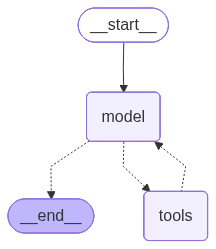

In [13]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent 노드: rbac_tool_filter가 역할(admin/editor/viewer)에 따라 도구를 필터링해요
# admin: 모든 도구 / editor: delete_data 제외 / viewer: read_data만 허용
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [14]:
# admin: 동일한 삭제 요청
# === admin이 삭제 시도 ===
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Users 테이블에서 ID=abc 레코드를 삭제해줘요"}]},
    context=RBACContext(user_role="admin", subscription="premium"),
)
print("응답:", result["messages"][-1].content)

[RBAC] admin → 모든 도구 허용 (3개)
[RBAC] admin → 모든 도구 허용 (3개)
응답: Users 테이블에서 ID가 abc인 레코드를 성공적으로 삭제했습니다.


## 4. Tool Context: 도구에서 데이터 소스 읽기/쓰기

Tool Context는 **도구 함수가 실행되는 동안 사용할 수 있는 컨텍스트**예요. LLM은 도구의 일반 인자(`query`, `password` 등)만 채우고, `ToolRuntime`은 LangChain 런타임이 자동으로 주입합니다.

도구 안에서는 `ToolRuntime`을 통해 세 가지 데이터 소스에 접근할 수 있어요.

- `runtime.context`: 호출 시 서버가 넣어준 Runtime Context (`user_id`, 권한, 환경 등)
- `runtime.state`: 현재 대화의 State (`messages`, 인증 상태, 세션 정보 등)
- `runtime.store`: 대화 밖에도 유지되는 장기 Store (선호도, 히스토리 등)

Model Context와의 차이는 **쓰기(write)** 가능성입니다. Model Context는 주로 "이번 호출에 무엇을 보여줄까"에 가깝지만, Tool Context는 `Command(update=...)`나 `store.put()`을 통해 이후 턴에도 남는 값을 만들 수 있어요.

> 🎯 **강의 포인트**: `ToolRuntime`은 도구 함수의 **특별한 매개변수**예요. 에이전트가 도구를 호출할 때 자동으로 주입되므로, LLM이 이 인자를 채울 필요가 없어요. `ToolRuntime[ContextType]` 타입 힌트로 Runtime Context 타입도 지정할 수 있습니다.


### 4-1. State에서 읽기 (`runtime.state`)

In [15]:
# ToolRuntime import (도구에서 State/Store에 접근해요)
from langchain.tools import ToolRuntime


@tool
def check_session_status(runtime: ToolRuntime) -> str:
    """현재 세션의 인증 상태와 사용자 정보를 확인해요."""
    # runtime.state로 현재 State에 접근
    current_state = runtime.state

    is_authenticated = current_state.get("authenticated", False)
    user_name = current_state.get("user_name", "알 수 없음")
    session_start = current_state.get("session_start", "알 수 없음")

    if is_authenticated:
        return f"인증됨 - 사용자: {user_name}, 세션 시작: {session_start}"
    else:
        return "인증되지 않음 - 로그인이 필요해요"


# 🔑 핵심: ToolRuntime이 runtime.state에서 커스텀 필드를 읽으려면
# state_schema=SessionAgentState를 반드시 지정해야 해요.
# 표준 AgentState는 messages만 지원하므로, invoke()에서 전달한
# "authenticated", "user_name", "session_start" 값이
# runtime.state에서 None 또는 기본값으로 반환돼요.
agent = create_agent(
    model=model,
    tools=[check_session_status],
    state_schema=SessionAgentState,   # 커스텀 State 스키마 등록
)

# State에 인증 정보를 포함해서 호출
result = agent.invoke({
    "messages": [{"role": "user", "content": "내 세션 상태를 확인해줘요"}],
    "authenticated": True,
    "user_name": "철수",
    "session_start": "2024-01-15 09:30",
})

print("응답:", result["messages"][-1].content)

응답: 현재 세션 상태는 인증됨입니다. 사용자 이름은 철수이며, 세션은 2024년 1월 15일 09:30에 시작되었습니다.


### 4-2. Store에서 읽기 (`runtime.store`)

Store는 대화 세션을 넘어 지속되는 장기 데이터를 저장해요. `ToolRuntime[ContextType]` 타입 힌트로 Runtime Context 타입을 함께 지정할 수 있어요.

In [ ]:
# Store 읽기용 Context 스키마
@dataclass
class StoreContext:
    user_id: str


@tool
def get_user_preferences(runtime: ToolRuntime[StoreContext]) -> str:
    """Store에서 사용자 설정값을 조회해요."""
    # Runtime Context에서 user_id 추출
    user_id = runtime.context.user_id

    # Store에서 사용자 데이터 읽기
    store = runtime.store
    prefs = store.get(("user_settings",), user_id)

    if prefs:
        return f"설정값: {prefs.value}"
    else:
        return f"user_id={user_id}의 설정값이 없어요"


# Store 초기화 및 데이터 삽입
store = InMemoryStore()
store.put(
    ("user_settings",),
    "user_001",
    {"language": "ko", "theme": "dark", "notifications": True}
)

agent = create_agent(
    model=model,
    tools=[get_user_preferences],
    context_schema=StoreContext,
    store=store,
)

# 설정 조회
result = agent.invoke(
    {"messages": [{"role": "user", "content": "내 설정값을 알려줘요"}]},
    context=StoreContext(user_id="user_001"),
)
print("응답:", result["messages"][-1].content)

응답: 당신의 설정값은 다음과 같습니다:

- **언어**: 한국어 (ko)
- **테마**: 어두운 테마 (dark)
- **알림**: 활성화 (True)


### 4-3. State에 쓰기 (`Command(update=...)`)

도구에서 `Command(update={...})`를 반환하면 State를 직접 업데이트할 수 있어요. 인증 도구가 인증 상태를 State에 기록하거나, 세션 데이터를 저장하는 패턴에 사용해요.

> ⚠️ **자주 하는 실수**: `Command`를 반환하는 도구는 반드시 `ToolMessage`도 함께 반환해야 해요. `tool_call_id`가 없으면 에러가 발생해요.

In [17]:
# Command와 ToolMessage import
from langgraph.types import Command
from langchain.messages import ToolMessage


@tool
def authenticate_user(password: str, runtime: ToolRuntime) -> Command:
    """비밀번호를 확인하고 인증 상태를 State에 업데이트해요."""
    # State의 메시지에서 현재 도구 호출 ID를 찾아요
    messages = runtime.state.get("messages", [])
    tool_call_id = None
    for msg in reversed(messages):
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                if tc.get("name") == "authenticate_user":
                    tool_call_id = tc.get("id")
                    break
            if tool_call_id:
                break

    # 인증 로직 (실제 환경에서는 DB 조회 등을 수행해요)
    if password == "secret123":
        return Command(
            update={
                "authenticated": True,   # State 업데이트: 인증 상태
                "messages": [
                    ToolMessage(
                        content="인증 성공! 이제 모든 기능을 사용할 수 있어요.",
                        tool_call_id=tool_call_id,
                    )
                ],
            }
        )
    else:
        return Command(
            update={
                "authenticated": False,   # State 업데이트: 인증 실패
                "messages": [
                    ToolMessage(
                        content="인증 실패 - 비밀번호가 올바르지 않아요.",
                        tool_call_id=tool_call_id,
                    )
                ],
            }
        )


# 🔑 핵심: Command(update={"authenticated": ...})가 실제로 State에 반영되려면
# state_schema=SessionAgentState를 지정해야 해요.
# 스키마 없이는 "authenticated" 키가 State에 등록되지 않아
# Command(update=...)가 무시되거나 에러가 발생해요.
agent = create_agent(
    model=model,
    tools=[authenticate_user, check_session_status],
    state_schema=SessionAgentState,   # 커스텀 State 스키마 등록
)

# 올바른 비밀번호로 인증 후 상태 확인
result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "비밀번호 'secret123'으로 인증하고, 세션 상태를 확인해줘요"
    }]
})

print("최종 응답:", result["messages"][-1].content)
print("State의 authenticated:", result.get("authenticated", False))

최종 응답: 비밀번호 'secret123'으로 인증한 결과는 "인증 성공! 이제 모든 기능을 사용할 수 있어요."입니다. 그러나 현재 세션 상태는 "인증되지 않음 - 로그인이 필요해요."로 나타납니다. 
State의 authenticated: True


### 4-4. Store에 쓰기 (`runtime.store.put()`)

In [18]:
@tool
def save_user_preference(
    key: str, value: str, runtime: ToolRuntime[StoreContext]
) -> str:
    """사용자 설정값을 Store에 저장해요. 여러 대화 세션에서 유지되어요."""
    user_id = runtime.context.user_id
    store = runtime.store

    # 기존 설정 읽기 (있으면 병합, 없으면 새로 생성)
    existing = store.get(("user_settings",), user_id)
    settings = existing.value.copy() if existing else {}

    # 새 설정 저장
    settings[key] = value
    store.put(("user_settings",), user_id, settings)

    return f"설정 저장 완료: {key} = {value}"


store = InMemoryStore()

agent = create_agent(
    model=model,
    tools=[save_user_preference, get_user_preferences],
    context_schema=StoreContext,
    store=store,
)

# 설정 저장
result = agent.invoke(
    {"messages": [{"role": "user", "content": "테마를 'dark'로 설정해줘요"}]},
    context=StoreContext(user_id="user_new"),
)
print("저장 후:", result["messages"][-1].content)

# 저장된 설정 확인 (새 대화에서도 유지됨)
result = agent.invoke(
    {"messages": [{"role": "user", "content": "내 현재 설정값을 알려줘요"}]},
    context=StoreContext(user_id="user_new"),
)
print("조회 결과:", result["messages"][-1].content)

저장 후: 테마를 'dark'로 설정했습니다!
조회 결과: 현재 설정값은 다음과 같습니다: `theme` - `dark`.


## 5. Life-cycle Context: SummarizationMiddleware

Life-cycle Context는 "모델에게 무엇을 보여줄까"나 "도구가 무엇을 저장할까"보다 한 단계 바깥에 있는 개념이에요. 에이전트가 실행되는 동안 **모델 호출 전후, 도구 호출 전후, 전체 실행 시작/종료 시점**에 공통 처리를 넣는 영역입니다.

대표적인 예시는 다음과 같아요.

- 대화가 길어지면 오래된 메시지를 요약하기
- 위험한 요청을 가드레일로 차단하기
- 도구 호출 결과와 비용을 로깅하기
- 특정 조건에서 실행 흐름을 건너뛰거나 중단하기

여기서는 가장 이해하기 쉬운 예로 `SummarizationMiddleware`를 사용합니다. 대화 히스토리가 너무 길어지면 오래된 메시지를 요약으로 대체해 **State를 영구적으로 수정**해요. 따라서 이후 턴은 원본 긴 메시지 대신 요약된 맥락을 보게 됩니다.

> 💡 **실무 팁**: `SummarizationMiddleware`는 `trigger=("tokens", N)`으로 토큰 수 기준, `trigger=("messages", N)`으로 메시지 수 기준으로 요약을 트리거할 수 있어요. `keep=("messages", N)`으로 요약 후 보존할 최근 메시지 수를 지정해요.


In [19]:
# SummarizationMiddleware import
from langchain.agents.middleware import SummarizationMiddleware

# Life-cycle 미들웨어가 포함된 에이전트 생성
agent = create_agent(
    model=model,
    tools=[search_tool],
    middleware=[
        SummarizationMiddleware(
            model="openai:gpt-4o-mini",    # 요약에 사용할 모델
            trigger=("tokens", 4000),      # 4000 토큰 초과 시 요약 트리거
            keep=("messages", 10),         # 요약 후 최근 10개 메시지 보존
        ),
    ],
)

# 요약 테스트 (대화가 길어지면 자동으로 요약돼요)
result = agent.invoke({
    "messages": [{"role": "user", "content": "LangGraph의 컨텍스트 엔지니어링에 대해 설명해줘요"}]
})

print("응답:", result["messages"][-1].content[:300])

응답: LangGraph의 컨텍스트 엔지니어링은 자연어 처리(NLP) 모델의 효과적인 활용을 위해 설계된 기술입니다. 이 시스템은 사용자가 특정 작업이나 목표를 달성하기 위해 필요한 정보를 컨텍스트 형태로 제공하는 방식을 중점적으로 다룹니다. LangGraph는 다음과 같은 특징과 기능을 포함합니다:

1. **정보 구조화**: 컨텍스트 엔지니어링은 대화 또는 텍스트의 맥락을 이해하고 구조화하여, 모델이 더 잘 반응할 수 있도록 합니다.
  
2. **적응형 입력 생성**: 사용자의 요구와 환경에 따라 적절한 프롬프트를 생성하고 조정하여,


## 6. 종합 예제: 멀티 레이어 컨텍스트 엔지니어링

지금까지는 컨텍스트 결정을 하나씩 분리해서 봤어요. 실무에서는 보통 여러 결정을 동시에 적용합니다. 예를 들어 구독 기반 퍼스널 어시스턴트는 다음 질문을 한 번에 해결해야 해요.

1. **이 사용자는 누구인가?** → Runtime Context의 `user_id`, `user_role`, `subscription`
2. **이 사용자에게 어떤 말투와 안내를 줄 것인가?** → `@dynamic_prompt`로 Model Context 변경
3. **이 사용자가 어떤 도구를 볼 수 있는가?** → `@wrap_model_call`로 도구 목록 필터링
4. **검색 히스토리를 어디에 저장하고 다시 읽을 것인가?** → `ToolRuntime`과 Store로 Tool Context 처리

이 예제는 다음을 동시에 적용해요.

- **Runtime Context** → 사용자 역할 + 구독 등급
- **Store** → 사용자 검색 히스토리 (장기 메모리)
- **`@dynamic_prompt`** → 역할/등급 기반 시스템 프롬프트
- **`@wrap_model_call`** → 구독 등급 기반 도구 필터링
- **`ToolRuntime`** → 도구에서 Store 읽기/쓰기

> 🎯 **강의 포인트**: 미들웨어는 `middleware=[m1, m2, m3]` 리스트로 조합해요. 순서대로 적용되므로 `@dynamic_prompt` → `@wrap_model_call` 순으로 나열하면 프롬프트 설정 후 도구 필터링이 이루어져요. 이때 각 미들웨어가 "어떤 데이터 소스를 읽고 어떤 컨텍스트 타입을 바꾸는지"를 주석으로 남겨두면 유지보수가 쉬워집니다.


In [20]:
# ---------------------------------------------------
# 종합 예제: 구독 기반 퍼스널 어시스턴트
# ---------------------------------------------------

# Context 스키마: 역할 + 구독 등급 + user_id
@dataclass
class AssistantContext:
    user_id: str
    user_role: str          # "admin", "user"
    subscription: str       # "premium", "basic", "free"


# 도구 정의
@tool
def get_search_history(runtime: ToolRuntime[AssistantContext]) -> str:
    """사용자의 최근 검색 히스토리를 Store에서 가져와요."""
    user_id = runtime.context.user_id
    history = runtime.store.get(("search_history",), user_id)
    if history:
        searches = history.value.get("searches", [])
        return f"최근 검색어: {searches}"
    return "검색 히스토리가 없어요"


@tool
def save_search(query: str, runtime: ToolRuntime[AssistantContext]) -> str:
    """검색어를 Store의 히스토리에 저장해요."""
    user_id = runtime.context.user_id
    store = runtime.store

    existing = store.get(("search_history",), user_id)
    searches = existing.value.get("searches", []) if existing else []

    # 최근 5개만 유지
    searches.append(query)
    store.put(("search_history",), user_id, {"searches": searches[-5:]})
    return f"검색어 저장: {query}"


@tool
def premium_analysis(data: str, runtime: ToolRuntime[AssistantContext]) -> str:
    """심층 분석을 수행해요 (프리미엄 전용)."""
    # 런타임에 구독 등급 확인 (이중 보호)
    if runtime.context.subscription != "premium":
        return "프리미엄 구독이 필요한 기능이에요"
    return f"심층 분석 결과: {data}에 대한 상세 인사이트 생성 완료"


# 1. 역할과 구독 기반 동적 프롬프트
@dynamic_prompt
def subscription_prompt(request: ModelRequest) -> str:
    """구독 등급과 역할에 따라 프롬프트를 조정해요"""
    role = request.runtime.context.user_role
    tier = request.runtime.context.subscription

    base = "당신은 개인 어시스턴트예요."

    if role == "admin":
        base += " 관리자 권한으로 모든 기능에 접근할 수 있어요."

    if tier == "premium":
        base += " 이 사용자는 프리미엄 구독자예요 — 심층 분석 포함 모든 기능이 활성화되어 있어요."
    elif tier == "basic":
        base += " 베이직 구독자예요 — 기본 기능이 사용 가능해요."
    else:
        base += " 무료 플랜 사용자예요 — 기본 검색만 가능해요. 프리미엄 기능 업그레이드를 안내해요."

    return base


# 2. 구독 등급 기반 도구 필터링
@wrap_model_call
def subscription_tool_filter(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """구독 등급에 따라 도구 접근을 제한해요"""
    tier = request.runtime.context.subscription

    if tier != "premium":
        # 프리미엄 아닌 경우: 심층 분석 도구 숨김
        tools = [t for t in request.tools if t.name != "premium_analysis"]
        request = request.override(tools=tools)
        print(f"[필터] {tier} 구독 → premium_analysis 제외")

    return handler(request)


# Store 초기화 (기존 히스토리 설정)
store = InMemoryStore()
store.put(
    ("search_history",),
    "prem_user",
    {"searches": ["LangGraph", "AI 에이전트"]}
)

# 에이전트 생성 (여러 미들웨어 조합)
combined_agent = create_agent(
    model=model,
    tools=[get_search_history, save_search, premium_analysis],
    middleware=[
        subscription_prompt,        # 1. 동적 시스템 프롬프트
        subscription_tool_filter,   # 2. 도구 필터링
    ],
    context_schema=AssistantContext,
    store=store,
)

# === 프리미엄 사용자 ===
result = combined_agent.invoke(
    {"messages": [{"role": "user", "content": "내 검색 히스토리를 보여주고, LangGraph 심층 분석을 해줘요"}]},
    context=AssistantContext(
        user_id="prem_user",
        user_role="user",
        subscription="premium"
    ),
)
print("응답:", result["messages"][-1].content)

응답: 당신의 검색 히스토리는 다음과 같습니다:

- 최근 검색어: ['LangGraph', 'AI 에이전트']

또한, **LangGraph**에 대한 심층 분석이 완료되었습니다. 추가적인 인사이트가 필요한 경우 말씀해 주세요!


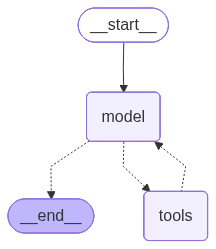

In [21]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent 노드: subscription_prompt(동적 프롬프트) + subscription_tool_filter(도구 필터링) 미들웨어 적용
# 프리미엄 사용자는 심층 분석 도구 사용 가능, 무료 사용자는 기본 도구만 제공돼요
from IPython.display import Image, display
display(Image(combined_agent.get_graph().draw_mermaid_png()))

In [22]:
# === 무료 사용자 ===
result = combined_agent.invoke(
    {"messages": [{"role": "user", "content": "LangGraph 심층 분석을 해줘요"}]},
    context=AssistantContext(
        user_id="free_user",
        user_role="user",
        subscription="free"
    ),
)
print("응답:", result["messages"][-1].content)

[필터] free 구독 → premium_analysis 제외
[필터] free 구독 → premium_analysis 제외
응답: LangGraph에 대한 심층 분석을 원하신다면, LangGraph의 개념, 기능, 사용 사례 및 이점 등을 다룰 수 있습니다. LangGraph는 특정 문제를 해결하기 위한 그래프 기반의 언어 모델링 도구입니다. 이를 통해 텍스트 데이터를 시각화하고, 언어적 패턴을 분석할 수 있습니다.

1. **개념**: LangGraph는 자연어 처리(NLP)와 그래프 이론을 결합하여 언어 데이터를 효과적으로 모델링합니다.
   
2. **기능**:
   - 텍스트 데이터에서 그래프 생성
   - 언어적 관계 시각화
   - 언어 패턴 분석 및 인사이트 제공

3. **사용 사례**: 
   - 소셜 미디어의 트렌드 분석
   - 고객 피드백 및 리뷰 분석
   - 문서 간의 유사성 측정

4. **이점**:
   - 복잡한 데이터 구조를 이해하기 쉽게 시각화
   - 패턴 분석을 통해 의사결정에 도움
   - 실시간 데이터 분석 가능

더 심층적으로 다뤄야 할 특정 부분이 있다면 말씀해 주세요!


## 실습 해설: 사용자 등급별 응답 차별화

아래 완성 예제는 `gold` / `silver` / `bronze` 등급에 따라 **프롬프트**와 **사용 가능한 도구 목록**을 동시에 바꾸는 패턴을 보여줘요.

In [23]:
# ============================================================
# 실습 해설: membership_tier에 따라 도구 접근과 프롬프트가 달라지는 에이전트
#   - gold: 모든 도구 + VIP 프롬프트
#   - silver: 기본/고급 도구만 + 일반 프롬프트
#   - bronze: 읽기 전용 도구만 + 업그레이드 안내 프롬프트
# ============================================================

@tool
def read_only_search(query: str) -> str:
    """기본 검색 (모든 등급)"""
    return f"기본 검색 결과: {query}"


@tool
def advanced_filter(query: str, filter_type: str) -> str:
    """고급 필터 검색 (silver 이상)"""
    return f"필터 검색 결과: {query} (필터: {filter_type})"


@tool
def premium_feature(data: str) -> str:
    """프리미엄 기능 (gold 전용)"""
    return f"프리미엄 처리 결과: {data}"


@dataclass
class MembershipContext:
    membership_tier: str  # "gold", "silver", "bronze"


@dynamic_prompt
def membership_prompt(request: ModelRequest) -> str:
    """멤버십 등급에 따라 시스템 프롬프트를 바꿔요."""
    tier = request.runtime.context.membership_tier
    base = "당신은 멤버십 기반 고객 지원 어시스턴트예요."

    if tier == "gold":
        return base + "\nVIP 서비스를 이용해 주셔서 감사합니다. 모든 도구를 활용해 가장 적극적으로 도와주세요."
    if tier == "silver":
        return base + "\n실버 회원입니다. 기본 검색과 고급 필터를 활용하되 프리미엄 전용 기능은 안내만 해주세요."
    return base + "\n브론즈 회원입니다. 읽기 전용 검색만 사용할 수 있으며, 필요한 경우 업그레이드를 부드럽게 안내하세요."


@wrap_model_call
def membership_tool_filter(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """멤버십 등급에 따라 모델에 노출되는 도구 목록을 제한해요."""
    tier = request.runtime.context.membership_tier

    if tier == "gold":
        allowed_tools = request.tools
    elif tier == "silver":
        allowed_tools = [tool for tool in request.tools if tool.name != "premium_feature"]
    else:
        allowed_tools = [tool for tool in request.tools if tool.name == "read_only_search"]

    print(f"[멤버십 필터] {tier} → {[tool.name for tool in allowed_tools]}")
    return handler(request.override(tools=allowed_tools))


membership_agent = create_agent(
    model=model,
    tools=[read_only_search, advanced_filter, premium_feature],
    middleware=[membership_prompt, membership_tool_filter],
    context_schema=MembershipContext,
)

print("=== gold 사용자 ===")
gold_result = membership_agent.invoke(
    {"messages": [{"role": "user", "content": "LangGraph 교육 상품을 검색하고 고급 필터와 프리미엄 기능까지 사용해 분석해줘요."}]},
    context=MembershipContext(membership_tier="gold"),
)
print(gold_result["messages"][-1].content)

print("\n=== bronze 사용자 ===")
bronze_result = membership_agent.invoke(
    {"messages": [{"role": "user", "content": "LangGraph 교육 상품을 검색하고 프리미엄 분석도 해줘요."}]},
    context=MembershipContext(membership_tier="bronze"),
)
print(bronze_result["messages"][-1].content)

=== gold 사용자 ===
[멤버십 필터] gold → ['read_only_search', 'advanced_filter', 'premium_feature']
[멤버십 필터] gold → ['read_only_search', 'advanced_filter', 'premium_feature']
이용해 주셔서 감사합니다! 

1. **고급 필터 검색 결과**: LangGraph 교육 상품에 대한 고급 필터 검색 결과가 나왔습니다. 이 필터를 통해 더욱 구체적이고 맞춤화된 정보를 확인할 수 있습니다.

2. **프리미엄 기능 분석 결과**: LangGraph 교육 상품에 대한 프리미엄 분석이 완료되었습니다. 이 분석을 통해 상품의 특성, 장점, 그리고 가치를 더욱 깊이 이해할 수 있습니다.

추가로 필요한 정보가 있거나 더 궁금한 점이 있으시면 말씀해 주세요!

=== bronze 사용자 ===
[멤버십 필터] bronze → ['read_only_search']
[멤버십 필터] bronze → ['read_only_search']
현재 브론즈 회원으로서는 LangGraph 교육 상품과 프리미엄 분석에 대한 자세한 정보를 검색할 수 있지만, 구체적인 내용은 자세히 확인할 수 없습니다. 

더 많은 정보를 원하신다면, 프리미엄 회원으로 업그레이드하여 보다 폭넓은 검색과 분석 기능을 이용해 보시는 것을 추천드립니다. 도움이 필요하시면 언제든지 말씀해 주세요!


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **컨텍스트 3종류**: Model Context(Transient - 단일 호출), Tool Context(Persistent - State/Store 쓰기), Life-cycle Context(Persistent - 요약/가드레일)
- **데이터 소스 3종류**: Runtime Context(호출 시 주입되는 정적 구성값), State(대화 세션 단기 메모리), Store(대화 간 장기 메모리)
- **`@dynamic_prompt`**: State, Store, Runtime Context를 읽어 시스템 프롬프트를 동적으로 생성해요
- **`@wrap_model_call`**: 메시지 주입, 도구 필터링, 모델 선택, 응답 형식을 런타임에 제어해요
- **RBAC 구현**: `@wrap_model_call` + Runtime Context로 역할 기반 도구 접근 제어를 구현해요
- **`ToolRuntime`**: 도구 함수에서 State/Store/Context에 접근하는 특별 매개변수 (LLM이 채우지 않아요)
- **`Command(update=...)`**: 도구에서 State를 영구적으로 업데이트하는 방법
- **`SummarizationMiddleware`**: 토큰 초과 시 자동 요약으로 대화 히스토리를 압축해요

## 다음 노트북 예고

다음 `04-Prebuilt-Middleware.ipynb`에서는 **LangChain V1이 기본 제공하는 12+ 내장 미들웨어**를 배워요. Summarization, PII 보호, 호출 횟수 제한, Fallback, Tool Retry, LLM-as-ToolSelector, TodoList, Context Editing 등 자주 쓰는 패턴이 이미 구현돼 있어요. 이번 노트북에서 익힌 컨텍스트 3요소가 각 내장 미들웨어에 어떻게 녹아 있는지 확인해볼게요.